# From Accuracy to Accountability: Stress Testing a Predictive Model

This notebook implements a COMPAS reliability audit pipeline. The audit evaluates distribution drift, generalization, spurious-correlation risk, robustness under stress, and subgroup fairness. The goal is not only to report model performance, but to interpret whether the models appear stable enough for responsible deployment.

## 0. Setup And Data

The notebook downloads the COMPAS dataset directly from ProPublica's public GitHub repository, so no local data file is required. The preprocessing follows the documented COMPAS inclusion criteria used throughout the analysis.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.stats import ks_2samp
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, confusion_matrix
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
RANDOM_STATE = 42

In [2]:
# Load COMPAS data from ProPublica's public repository.
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

selected_cols = [
    "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
    "priors_count", "days_b_screening_arrest", "decile_score", "is_recid",
    "two_year_recid", "c_jail_in", "c_jail_out",
    "juv_fel_count", "juv_misd_count", "juv_other_count",
]

df = raw_data[selected_cols].copy()

# COMPAS / ProPublica inclusion filters.
df = df[
    (df["days_b_screening_arrest"].between(-30, 30)) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["score_text"] != "N/A")
].copy()

count_features = ["priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count"]
numeric_features = count_features + ["two_year_recid"]

for col in numeric_features:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Analysis factors and target.
df["crime_factor"] = df["c_charge_degree"].astype("category")
df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45"] + [c for c in df["age_cat"].unique() if c != "25 - 45"],
)
df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian"] + [c for c in df["race"].unique() if c != "Caucasian"],
)
df["gender_factor"] = pd.Categorical(
    df["sex"].map({"Female": "Female", "Male": "Male"}),
    categories=["Male", "Female"],
)
df["score_binary"] = (df["score_text"] != "Low").astype(int)

categorical_features = ["gender_factor", "age_factor", "race_factor", "crime_factor"]
features = categorical_features + numeric_features
target = "score_binary"

X = df[features].copy()
y = df[target].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

summary = pd.DataFrame({
    "item": ["filtered_rows", "train_rows", "test_rows", "target_high_score_rate"],
    "value": [len(df), len(X_train), len(X_test), round(y.mean(), 4)],
})
display(summary)

,item,value
0,filtered_rows,6172.0000
1,train_rows,4937.0000
2,test_rows,1235.0000
3,target_high_score_rate,0.4457


The filtered dataset contains 6,172 records, with an 80/20 train-test split. The target is whether the COMPAS score is above "Low," matching the modeling task of high-risk score assignment rather than directly predicting a new criminal outcome.

In [3]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "Gradient-Boosted Tree": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(
            n_estimators=200,
            max_depth=4,
            random_state=RANDOM_STATE,
        )),
    ]),
}

for model in models.values():
    model.fit(X_train, y_train)

print("Models trained: Logistic Regression baseline and Gradient-Boosted Tree challenger")

Models trained: Logistic Regression baseline and Gradient-Boosted Tree challenger


The logistic regression model is the interpretable baseline. The gradient-boosted tree is a higher-capacity challenger, so the audit should check whether any performance gain comes with larger generalization or robustness risk.

## Helper Functions

In [4]:
def psi_numeric(train_values, test_values, bins=10, eps=1e-6):
    train_values = pd.to_numeric(pd.Series(train_values), errors="coerce").dropna().values
    test_values = pd.to_numeric(pd.Series(test_values), errors="coerce").dropna().values

    if len(train_values) == 0 or len(test_values) == 0:
        return np.nan

    cut_points = np.unique(np.quantile(train_values, np.linspace(0, 1, bins + 1)))
    if len(cut_points) < 3:
        lo = min(train_values.min(), test_values.min())
        hi = max(train_values.max(), test_values.max())
        if lo == hi:
            return 0.0
        cut_points = np.linspace(lo, hi, bins + 1)

    cut_points[0] = -np.inf
    cut_points[-1] = np.inf

    train_counts, _ = np.histogram(train_values, bins=cut_points)
    test_counts, _ = np.histogram(test_values, bins=cut_points)

    train_pct = np.clip(train_counts / train_counts.sum(), eps, None)
    test_pct = np.clip(test_counts / test_counts.sum(), eps, None)

    return float(np.sum((train_pct - test_pct) * np.log(train_pct / test_pct)))


def _to_dense(x):
    return x.toarray() if hasattr(x, "toarray") else np.asarray(x)


def mmd_rbf(X_a, X_b, gamma=None, max_n=500, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    X_a = _to_dense(X_a)
    X_b = _to_dense(X_b)

    if X_a.shape[0] > max_n:
        X_a = X_a[rng.choice(X_a.shape[0], size=max_n, replace=False)]
    if X_b.shape[0] > max_n:
        X_b = X_b[rng.choice(X_b.shape[0], size=max_n, replace=False)]

    if gamma is None:
        gamma = 1.0 / X_a.shape[1]

    K_xx = rbf_kernel(X_a, X_a, gamma=gamma)
    K_yy = rbf_kernel(X_b, X_b, gamma=gamma)
    K_xy = rbf_kernel(X_a, X_b, gamma=gamma)
    np.fill_diagonal(K_xx, 0.0)
    np.fill_diagonal(K_yy, 0.0)

    m = X_a.shape[0]
    n = X_b.shape[0]
    return float(K_xx.sum() / (m * (m - 1)) + K_yy.sum() / (n * (n - 1)) - 2.0 * K_xy.mean())


def evaluate_classifier(model, X_eval, y_eval):
    y_prob = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(y_eval, y_pred),
        "auc": roc_auc_score(y_eval, y_prob),
        "log_loss": log_loss(y_eval, y_prob),
        "mean_score": y_prob.mean(),
        "pred_high_rate": y_pred.mean(),
    }


def pairwise_swap_shift(model, X_eval, feature_col, value_a, value_b):
    work = X_eval.copy()
    mask = work[feature_col].astype(str).isin([value_a, value_b])
    if mask.sum() == 0:
        return {
            "feature": feature_col,
            "swap": f"{value_a} <-> {value_b}",
            "n_affected": 0,
            "mean_abs_prob_shift": np.nan,
            "mean_signed_shift": np.nan,
        }

    base_prob = model.predict_proba(work.loc[mask])[:, 1]
    cf = work.loc[mask].copy()
    cf[feature_col] = cf[feature_col].astype(str).map({value_a: value_b, value_b: value_a}).values
    cf_prob = model.predict_proba(cf)[:, 1]

    return {
        "feature": feature_col,
        "swap": f"{value_a} <-> {value_b}",
        "n_affected": int(mask.sum()),
        "mean_abs_prob_shift": float(np.mean(np.abs(cf_prob - base_prob))),
        "mean_signed_shift": float(np.mean(cf_prob - base_prob)),
    }


def stress_test_feature(model, X_eval, feature_col, deltas):
    rows = []
    base_min = X_eval[feature_col].min()
    base_max = X_eval[feature_col].max()

    for delta in deltas:
        X_s = X_eval.copy()
        X_s[feature_col] = np.clip(pd.to_numeric(X_s[feature_col]) + delta, base_min, base_max)
        prob = model.predict_proba(X_s)[:, 1]
        pred = (prob >= 0.5).astype(int)
        rows.append({
            "feature": feature_col,
            "delta": delta,
            "mean_pred_prob": prob.mean(),
            "median_pred_prob": np.median(prob),
            "share_pred_high_risk": pred.mean(),
        })
    return pd.DataFrame(rows)


def plot_ice_numeric(model, X_eval, feature_col, values, n_instances=6, random_state=RANDOM_STATE, ax=None, title=None):
    rng = np.random.default_rng(random_state)
    idx = rng.choice(X_eval.index, size=min(n_instances, len(X_eval)), replace=False)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))

    for i in idx:
        row = X_eval.loc[[i]].copy()
        preds = []
        for value in values:
            temp = row.copy()
            temp[feature_col] = value
            preds.append(model.predict_proba(temp)[:, 1][0])
        ax.plot(values, preds, alpha=0.75)

    ax.set_xlabel(feature_col)
    ax.set_ylabel("Predicted probability of high score")
    ax.set_title(title or f"ICE: {feature_col}")
    return ax


def global_sensitivity_index(model, X_eval, feature_col, values):
    mean_preds = []
    for value in values:
        X_s = X_eval.copy()
        X_s[feature_col] = value
        mean_preds.append(model.predict_proba(X_s)[:, 1].mean())

    mean_preds = np.array(mean_preds)
    return {
        "feature": feature_col,
        "sensitivity_index": float(np.var(mean_preds)),
        "range_mean_score": float(mean_preds.max() - mean_preds.min()),
        "min_mean_score": float(mean_preds.min()),
        "max_mean_score": float(mean_preds.max()),
    }


def slice_metrics(model, X_eval, y_eval, group_col):
    pred_prob = model.predict_proba(X_eval)[:, 1]
    pred = (pred_prob >= 0.5).astype(int)

    eval_df = X_eval[[group_col]].copy()
    eval_df["actual"] = y_eval.values
    eval_df["pred"] = pred
    eval_df["pred_prob"] = pred_prob

    rows = []
    for group, g in eval_df.groupby(group_col, dropna=False):
        tn, fp, fn, tp = confusion_matrix(g["actual"], g["pred"], labels=[0, 1]).ravel()
        rows.append({
            "slice_feature": group_col,
            "slice_value": str(group),
            "n": len(g),
            "accuracy": accuracy_score(g["actual"], g["pred"]),
            "auc": roc_auc_score(g["actual"], g["pred_prob"]) if g["actual"].nunique() > 1 else np.nan,
            "fpr": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "fnr": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "pred_high_rate": g["pred"].mean(),
            "mean_score": g["pred_prob"].mean(),
        })
    return pd.DataFrame(rows).sort_values("n", ascending=False)

## 1. Part A: Distribution Drift

This section checks whether the train and test distributions differ. PSI gives a practical stability measure, KS tests univariate distribution differences, MMD checks high-dimensional encoded feature drift, and score drift checks whether model outputs shift across splits.

In [5]:
drift_rows = []
for col in numeric_features:
    ks_stat, ks_p = ks_2samp(X_train[col], X_test[col])
    drift_rows.append({
        "feature": col,
        "train_mean": X_train[col].mean(),
        "test_mean": X_test[col].mean(),
        "PSI": psi_numeric(X_train[col], X_test[col]),
        "KS_stat": ks_stat,
        "KS_pvalue": ks_p,
    })

input_drift_table = pd.DataFrame(drift_rows).sort_values("PSI", ascending=False)
display(input_drift_table.round(4))

encoded_train = models["Logistic Regression"].named_steps["preprocessor"].transform(X_train)
encoded_test = models["Logistic Regression"].named_steps["preprocessor"].transform(X_test)
mmd_value = mmd_rbf(encoded_train, encoded_test)
print(f"MMD^2 in encoded feature space: {mmd_value:.6f}")

,feature,train_mean,test_mean,PSI,KS_stat,KS_pvalue
0,priors_count,3.2050,3.4121,0.0104,0.0335,0.2113
3,juv_other_count,0.1061,0.1287,0.0103,0.0180,0.8998
2,juv_misd_count,0.0914,0.0907,0.0085,0.0046,1.0000
1,juv_fel_count,0.0598,0.0575,0.0056,0.0034,1.0000
4,two_year_recid,0.4580,0.4437,0.0008,0.0142,0.9862


MMD^2 in encoded feature space: 0.000805


The numeric drift results are low. The largest PSI is about 0.0104 for `priors_count`, which is below the common 0.10 monitoring threshold, and the KS p-values do not indicate a strong train-test distribution difference. The encoded-space MMD value is also very small, so this random train-test split does not show meaningful input drift. This does not prove deployment stability, because a random split is weaker than an out-of-time validation design.

,model,train_mean_score,test_mean_score,PSI_score,KS_stat_score,KS_pvalue_score
0,Logistic Regression,0.4458,0.4481,0.0029,0.0161,0.9552
1,Gradient-Boosted Tree,0.4458,0.4507,0.0054,0.0175,0.9160


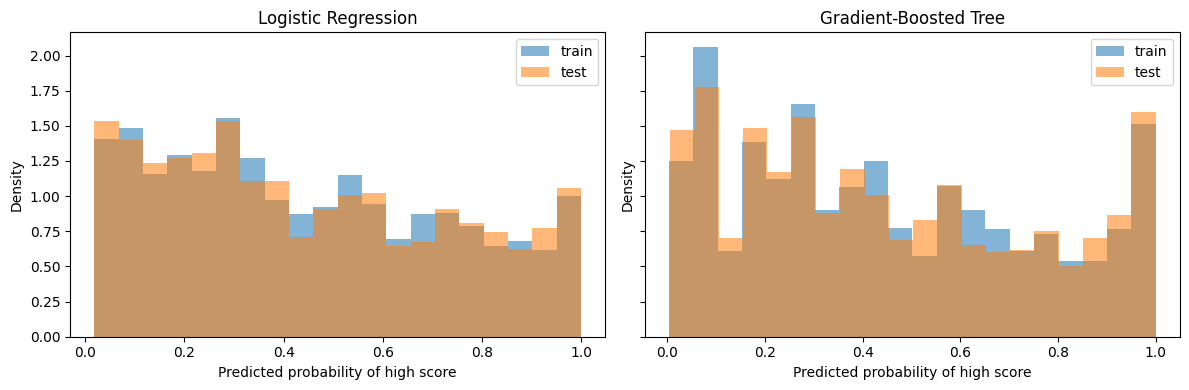

In [6]:
score_rows = []
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (name, model) in zip(axes, models.items()):
    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]
    ks_stat, ks_p = ks_2samp(train_prob, test_prob)
    score_rows.append({
        "model": name,
        "train_mean_score": train_prob.mean(),
        "test_mean_score": test_prob.mean(),
        "PSI_score": psi_numeric(train_prob, test_prob),
        "KS_stat_score": ks_stat,
        "KS_pvalue_score": ks_p,
    })

    ax.hist(train_prob, bins=20, alpha=0.55, label="train", density=True)
    ax.hist(test_prob, bins=20, alpha=0.55, label="test", density=True)
    ax.set_title(name)
    ax.set_xlabel("Predicted probability of high score")
    ax.set_ylabel("Density")
    ax.legend()

score_drift_table = pd.DataFrame(score_rows)
display(score_drift_table.round(4))
plt.tight_layout()
plt.show()

The score distributions are also stable across train and test. Both models have score PSI values below 0.01, and the train and test mean scores are close. The audit implication is that this split does not show score drift; however, production monitoring would still need score-drift checks because real deployment data can shift over time.

## 2. Part B: Generalization

This section compares train and test AUC, accuracy, and log loss. A large train-test gap would suggest overfitting or brittle reliance on sample-specific patterns.

In [7]:
generalization_rows = []
for name, model in models.items():
    train_metrics = evaluate_classifier(model, X_train, y_train)
    test_metrics = evaluate_classifier(model, X_test, y_test)
    generalization_rows.append({
        "model": name,
        "train_accuracy": train_metrics["accuracy"],
        "test_accuracy": test_metrics["accuracy"],
        "accuracy_gap_train_minus_test": train_metrics["accuracy"] - test_metrics["accuracy"],
        "train_auc": train_metrics["auc"],
        "test_auc": test_metrics["auc"],
        "auc_gap_train_minus_test": train_metrics["auc"] - test_metrics["auc"],
        "train_log_loss": train_metrics["log_loss"],
        "test_log_loss": test_metrics["log_loss"],
        "log_loss_gap_test_minus_train": test_metrics["log_loss"] - train_metrics["log_loss"],
    })

generalization_table = pd.DataFrame(generalization_rows)
display(generalization_table.round(4))

,model,train_accuracy,test_accuracy,accuracy_gap_train_minus_test,train_auc,test_auc,auc_gap_train_minus_test,train_log_loss,test_log_loss,log_loss_gap_test_minus_train
0,Logistic Regression,0.7525,0.7563,-0.0038,0.8304,0.8357,-0.0053,0.4990,0.4874,-0.0116
1,Gradient-Boosted Tree,0.7792,0.7466,0.0327,0.8591,0.8330,0.0261,0.4539,0.4935,0.0397


The logistic regression model generalizes slightly better on this split: its test AUC is about 0.836 and its train-test gaps are near zero. The gradient-boosted tree has higher train AUC but lower test AUC, with an AUC gap of about 0.026 and a log-loss gap of about 0.040. This suggests mild overfitting in the higher-capacity model, so any use of the tree model would need stronger validation and monitoring.

## 3. Part C: Spurious-Correlation Probe

Counterfactual swaps test whether selected attributes move predictions when all other observed fields are held fixed. These swaps are diagnostic tests, not causal proof, but large probability shifts can indicate shortcut learning or proxy reliance.

In [8]:
swap_specs = [
    ("race_factor", "African-American", "Caucasian"),
    ("gender_factor", "Female", "Male"),
    ("crime_factor", "F", "M"),
]

swap_tables = []
for name, model in models.items():
    model_swaps = pd.DataFrame([
        pairwise_swap_shift(model, X_test, feature, value_a, value_b)
        for feature, value_a, value_b in swap_specs
    ])
    model_swaps.insert(0, "model", name)
    swap_tables.append(model_swaps)

swap_table = pd.concat(swap_tables, ignore_index=True)
display(swap_table.round(4))

,model,feature,swap,n_affected,mean_abs_prob_shift,mean_signed_shift
0,Logistic Regression,race_factor,African-American <-> Caucasian,1046,0.0804,-0.0180
1,Logistic Regression,gender_factor,Female <-> Male,1235,0.0284,0.0168
2,Logistic Regression,crime_factor,F <-> M,1235,0.0418,-0.0117
3,Gradient-Boosted Tree,race_factor,African-American <-> Caucasian,1046,0.0896,-0.0224
4,Gradient-Boosted Tree,gender_factor,Female <-> Male,1235,0.0748,0.0118
5,Gradient-Boosted Tree,crime_factor,F <-> M,1235,0.0607,-0.0070


Race swaps create the largest average probability movement in both models: about 0.080 for logistic regression and 0.090 for the gradient-boosted tree. Gender and charge-type swaps also move predictions, but less consistently. The responsible ML concern is that a protected attribute or closely related proxy should not strongly influence risk-score assignment unless the decision context and legal framework justify its use.

## 4. Part D: Robustness

This section stress-tests count-based features and examines sensitivity to `priors_count`. A robust model should respond in a smooth, domain-plausible way rather than showing unstable jumps.

In [9]:
stress_specs = {
    "priors_count": [0, 2, 5, 10],
    "juv_fel_count": [0, 1, 2, 3],
    "juv_misd_count": [0, 1, 2, 3],
    "juv_other_count": [0, 1, 2, 3],
}

stress_tables = []
for name, model in models.items():
    pieces = []
    for feature, deltas in stress_specs.items():
        pieces.append(stress_test_feature(model, X_test, feature, deltas))
    model_stress = pd.concat(pieces, ignore_index=True)
    model_stress.insert(0, "model", name)
    stress_tables.append(model_stress)

stress_table = pd.concat(stress_tables, ignore_index=True)
display(stress_table.round(4))

,model,feature,delta,mean_pred_prob,median_pred_prob,share_pred_high_risk
0,Logistic Regression,priors_count,0,0.4481,0.4050,0.4089
1,Logistic Regression,priors_count,2,0.5323,0.5307,0.5206
2,Logistic Regression,priors_count,5,0.6571,0.7077,0.7215
3,Logistic Regression,priors_count,10,0.8292,0.8960,0.9126
4,Logistic Regression,juv_fel_count,0,0.4481,0.4050,0.4089
5,Logistic Regression,juv_fel_count,1,0.5284,0.5249,0.5190
6,Logistic Regression,juv_fel_count,2,0.6088,0.6419,0.6267
7,Logistic Regression,juv_fel_count,3,0.6855,0.7441,0.7474
8,Logistic Regression,juv_misd_count,0,0.4481,0.4050,0.4089
9,Logistic Regression,juv_misd_count,1,0.5066,0.4923,0.4850


Both models are highly sensitive to `priors_count`: increasing priors by 10 raises the predicted high-risk share from about 0.409 to above 0.89 in both models. The juvenile count features also affect predictions, with the tree model showing less smooth behavior for some count changes. This is a robustness flag because threshold-style jumps can be harder to justify and monitor than gradual changes.

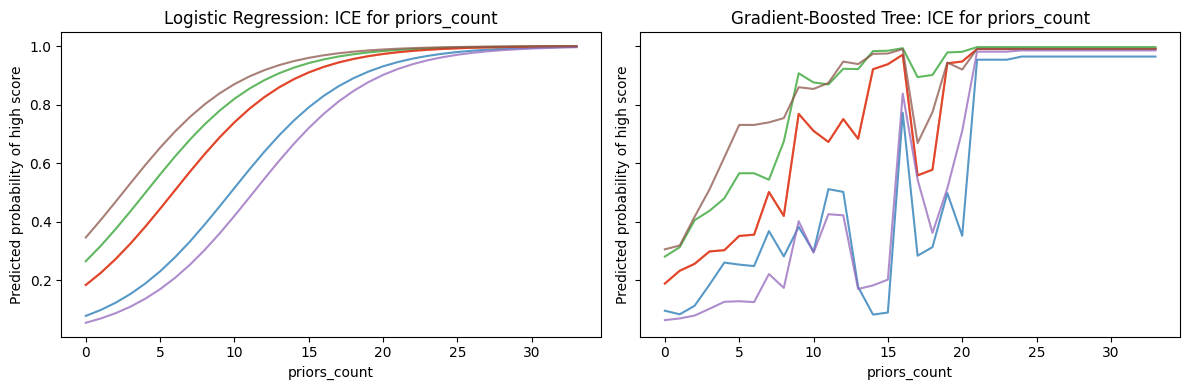

,model,feature,sensitivity_index,range_mean_score,min_mean_score,max_mean_score
0,Logistic Regression,priors_count,0.047269,0.696627,0.302094,0.998721
1,Gradient-Boosted Tree,priors_count,0.039124,0.671286,0.306952,0.978238


In [10]:
priors_grid = np.arange(int(X_test["priors_count"].min()), int(X_test["priors_count"].max()) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (name, model) in zip(axes, models.items()):
    plot_ice_numeric(
        model,
        X_test,
        feature_col="priors_count",
        values=priors_grid,
        n_instances=6,
        ax=ax,
        title=f"{name}: ICE for priors_count",
    )
plt.tight_layout()
plt.show()

sensitivity_rows = []
for name, model in models.items():
    row = global_sensitivity_index(model, X_test, "priors_count", priors_grid)
    row["model"] = name
    sensitivity_rows.append(row)

sensitivity_table = pd.DataFrame(sensitivity_rows)[[
    "model", "feature", "sensitivity_index", "range_mean_score", "min_mean_score", "max_mean_score"
]]
display(sensitivity_table.round(6))

The ICE curves and sensitivity table show that `priors_count` has a large effect on predicted high-risk probability. This sensitivity is not automatically inappropriate because prior history is relevant to the COMPAS score, but it should be documented and monitored. The audit question is whether the magnitude of the response is stable across subgroups and whether it creates disproportionate error burdens.

## 5. Part E: Slice-Based Evaluation

Slice-based evaluation checks whether aggregate performance hides subgroup failures. This section reports race, gender, and age slices for both models. Very small slices should be interpreted cautiously.

In [11]:
slice_features = ["race_factor", "gender_factor", "age_factor"]

slice_tables = []
for name, model in models.items():
    pieces = []
    for feature in slice_features:
        pieces.append(slice_metrics(model, X_test, y_test, feature))
    model_slices = pd.concat(pieces, ignore_index=True)
    model_slices.insert(0, "model", name)
    slice_tables.append(model_slices)

slice_table = pd.concat(slice_tables, ignore_index=True)
display(slice_table.round(4))

,model,slice_feature,slice_value,n,accuracy,auc,fpr,fnr,pred_high_rate,mean_score
0,Logistic Regression,race_factor,African-American,634,0.7366,0.8227,0.3525,0.2011,0.6151,0.5898
1,Logistic Regression,race_factor,Caucasian,412,0.7597,0.7947,0.1056,0.5391,0.2160,0.3157
2,Logistic Regression,race_factor,Hispanic,108,0.8241,0.8459,0.0633,0.4828,0.1852,0.3023
3,Logistic Regression,race_factor,Other,71,0.8028,0.8486,0.0185,0.7647,0.0704,0.1999
4,Logistic Regression,race_factor,Asian,8,0.7500,0.6667,0.0000,1.0000,0.0000,0.1554
5,Logistic Regression,race_factor,Native American,2,1.0000,1.0000,0.0000,0.0000,0.5000,0.6338
6,Logistic Regression,gender_factor,Male,1000,0.7670,0.8485,0.1916,0.2832,0.4290,0.4644
7,Logistic Regression,gender_factor,Female,235,0.7106,0.7817,0.1679,0.4592,0.3234,0.3786
8,Logistic Regression,age_factor,25 - 45,695,0.7626,0.8358,0.1528,0.3430,0.3770,0.4614
9,Logistic Regression,age_factor,Greater than 45,272,0.8272,0.8502,0.0498,0.5211,0.1618,0.2295


The slice results show that aggregate performance hides meaningful subgroup variation. For both models, African-American defendants have much higher false positive rates than Caucasian defendants, while Caucasian defendants have higher false negative rates. The age slices also show a high false positive rate for defendants under 25. Very small groups such as Asian and Native American defendants should not be overinterpreted because their sample sizes are too small for stable conclusions.

## 6. Final Audit Summary

In [12]:
audit_summary = pd.DataFrame([
    {
        "audit_area": "Distribution drift",
        "main_result": "Low PSI/KS drift and very small MMD in the random split",
        "governance_interpretation": "No train-test drift flag here, but production needs monitoring and out-of-time validation.",
    },
    {
        "audit_area": "Generalization",
        "main_result": "Logistic regression has near-zero gaps; GBT has a larger AUC/log-loss gap",
        "governance_interpretation": "The higher-capacity model shows mild overfitting risk.",
    },
    {
        "audit_area": "Spurious-correlation probe",
        "main_result": "Race swaps produce the largest mean probability shifts",
        "governance_interpretation": "Protected-attribute reliance requires justification or mitigation.",
    },
    {
        "audit_area": "Robustness",
        "main_result": "Priors and juvenile count stresses materially change high-risk rates",
        "governance_interpretation": "Count-feature sensitivity should be documented and monitored.",
    },
    {
        "audit_area": "Slice fairness",
        "main_result": "Race and age slices show large FPR/FNR differences",
        "governance_interpretation": "Aggregate metrics are insufficient for deployment approval.",
    },
])

display(audit_summary)

,audit_area,main_result,governance_interpretation
0,Distribution drift,Low PSI/KS drift and very small MMD in the ran...,"No train-test drift flag here, but production ..."
1,Generalization,Logistic regression has near-zero gaps; GBT ha...,The higher-capacity model shows mild overfitti...
2,Spurious-correlation probe,Race swaps produce the largest mean probabilit...,Protected-attribute reliance requires justific...
3,Robustness,Priors and juvenile count stresses materially ...,Count-feature sensitivity should be documented...
4,Slice fairness,Race and age slices show large FPR/FNR differe...,Aggregate metrics are insufficient for deploym...


Overall, the logistic regression model appears more stable than the gradient-boosted tree on this train-test split, even though both models show important subgroup and sensitivity concerns. The strongest audit findings are not input drift, but protected-attribute sensitivity, high count-feature sensitivity, and subgroup error disparities. A responsible deployment decision would require out-of-time validation, subgroup monitoring, threshold review, and documentation of why sensitive or proxy attributes are included.

Limitations: this notebook uses a random train-test split, so it does not fully simulate deployment drift. The target is COMPAS score category rather than an independent ground-truth risk outcome. Counterfactual swaps are diagnostic and should not be interpreted as causal proof.